In [1]:
%load_ext autoreload
%autoreload

In [2]:
%pylab inline

import jax
import jax.numpy as jnp
import jax_cosmo as jc

from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint
from jaxpm.pm import linear_field, lpt, make_ode_fn

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
mesh_shape= [256, 256, 256]
box_size  = [256.,256.,256.]
# snapshots = jnp.linspace(0.1,1.,2)
snapshots = jnp.linspace(0.1,1.,10)

@jax.jit
def run_simulation(omega_c, sigma8):
    # Create a small function to generate the matter power spectrum
    k = jnp.logspace(-4, 1, 128)
    pk = jc.power.linear_matter_power(jc.Planck15(Omega_c=omega_c, sigma8=sigma8), k)
    pk_fn = lambda x: jc.scipy.interpolate.interp(x.reshape([-1]), k, pk).reshape(x.shape)

    # Create initial conditions
    initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(0))

    # Create particles
    particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]),axis=-1).reshape([-1,3])

    cosmo = jc.Planck15(Omega_c=omega_c, sigma8=sigma8)
    
    # Initial displacement
    dx, p, f = lpt(cosmo, initial_conditions, particles, 0.1)
    
    # Evolve the simulation forward
    res = odeint(make_ode_fn(mesh_shape), [particles+dx, p], snapshots, cosmo, rtol=1e-5, atol=1e-5)
    
    # Return the simulation volume at requested 
    return res[0]

In [4]:
%%time
res = run_simulation(0.25, 0.8)

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:68: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype, copy=copy, device=device)
/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:68: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype, copy=copy, device=device)


(256, 256, 129)
(256, 256, 129)
CPU times: user 26.8 s, sys: 4.89 s, total: 31.7 s
Wall time: 15 s


NameError: name 'res' is not defined

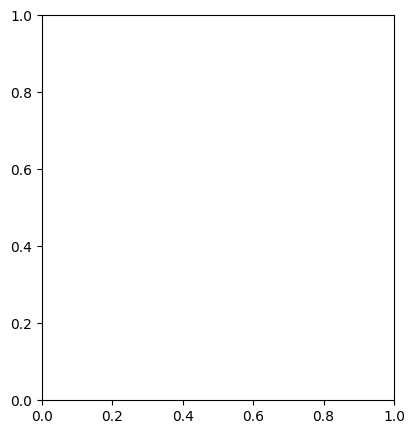

In [5]:
figure(figsize=[10,5])
subplot(121)
imshow(cic_paint(jnp.zeros(mesh_shape), res[0]).sum(axis=0),cmap='gist_stern')
subplot(122)
imshow(cic_paint(jnp.zeros(mesh_shape), res[1]).sum(axis=0),cmap='gist_stern')

In [6]:
kvec = jaxpm.kernels.fftk(mesh_shape)

In [14]:
kvec[0].shape

(256, 1, 1)

In [7]:
kk = sum(ki**2 for ki in kvec)

/scratch/tmp.14552766.athomsen/ipykernel_3788959/665030364.py:1: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  kk = sum(ki**2 for ki in kvec)


In [11]:
kk.shape

(256, 256, 129)

In [19]:
for i in range(3):
    print(kvec[i].shape)

(256, 1, 1)
(1, 256, 1)
(1, 1, 129)


### LPT

In [33]:
# def get_initial_displacements(omega_c, sigma8):
#     # Create a small function to generate the matter power spectrum
#     k = jnp.logspace(-4, 1, 128)
#     pk = jc.power.linear_matter_power(jc.Planck15(Omega_c=omega_c, sigma8=sigma8), k)
#     pk_fn = lambda x: jc.scipy.interpolate.interp(x.reshape([-1]), k, pk).reshape(x.shape)
    
#     # Create initial conditions
#     initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(0))
    
#     # Create particles
#     particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]), axis=-1).reshape([-1,3])
    
#     cosmo = jc.Planck15(Omega_c=omega_c, sigma8=sigma8)
    
#     # Initial displacement
#     dx, p, _ = lpt(cosmo, initial_conditions, particles, 0.1)

#     return particles + dx, p, cosmo

# pos_i, vel_i, cosmo = get_initial_displacements(0.25, 0.8)
# scales = jnp.linspace(0.1,1.,16)